<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week6_Day5_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
# ── Stack PyTorch + HuggingFace (juin 2025) ──────────────────────────────────
# POURQUOI torch au lieu de tensorflow ?
# → HuggingFace Transformers v5 est PyTorch-only
# → PyTorch est maintenant le standard de facto pour la recherche ET la production
# → >95% des papers NLP publiés en 2025 utilisent PyTorch

# Sur Google Colab (GPU T4 déjà installé, on complète) :
!pip install -q \
    transformers>=5.0.0 \
    datasets>=3.0.0 \
    evaluate>=0.4.0 \
    accelerate>=0.34.0 \
    scikit-learn>=1.5.0

# torch est pré-installé sur Colab — vérifier avec : import torch; print(torch.__version__)
# Si absent : pip install torch>=2.4.0

# POURQUOI datasets au lieu de tensorflow-datasets ?
# → Aucune dépendance protobuf conflictuelle
# → API plus simple, accès au même dataset IMDB
# → Standard HuggingFace 2025, utilisé par 99% des projets modernes

# VÉRIFICATION :
# pip show transformers torch datasets | grep -E "^(Name|Version)"


In [22]:
# ── Imports système ───────────────────────────────────────────────────────────
import platform, warnings
warnings.filterwarnings("ignore")

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import numpy as np

# ── HuggingFace — PyTorch uniquement ─────────────────────────────────────────
from transformers import (
    AutoTokenizer,                      # Détecte automatiquement le bon tokenizer
    BertForSequenceClassification,      # ← Version PyTorch (remplace TFBert*)
    Trainer,                            # Orchestre tout l'entraînement
    TrainingArguments,                  # Hyperparamètres de l'entraînement
    DataCollatorWithPadding,            # Padding dynamique par batch
)
from datasets import load_dataset       # ← HuggingFace datasets (remplace TFDS)
import evaluate
import matplotlib.pyplot as plt

# ── Diagnostic Hardware ───────────────────────────────────────────────────────
# POURQUOI ce check ?
# → Sur Colab : doit afficher "cuda" (GPU T4 = 16 GB VRAM)
# → Sur Mac M1/M2/M3 : affiche "mps" (GPU Apple Silicon)
# → Sur CPU : affiche "cpu" → entraînement ~8x plus lent, déconseillé

if torch.cuda.is_available():
    device = torch.device("cuda")
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✅ GPU CUDA : {gpu_name} ({vram_gb:.1f} GB VRAM)")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("✅ GPU Apple Silicon (MPS)")
else:
    device = torch.device("cpu")
    print("⚠️  CPU uniquement — entraînement lent (~2h pour 2 époques)")
    print("   → Sur Colab : Exécution → Modifier le type d'exécution → GPU T4")

print(f"\nPython    : {platform.python_version()}")
print(f"PyTorch   : {torch.__version__}")
print(f"Device    : {device}")

✅ GPU CUDA : Tesla T4 (15.6 GB VRAM)

Python    : 3.12.13
PyTorch   : 2.11.0+cu128
Device    : cuda


In [23]:
# ── Chargement du dataset IMDB avec le nom officiel 2025 ─────────────────────
# POURQUOI "stanfordnlp/imdb" et pas "imdb" ?
# → HuggingFace a migré tous les datasets "legacy" vers des namespaces explicites
# → La nouvelle validation huggingface_hub exige le format "namespace/nom"
# → "stanfordnlp" = Stanford NLP Group, propriétaire d'origine du dataset

raw_datasets = load_dataset("stanfordnlp/imdb")
print(raw_datasets)

# ── Aperçu ────────────────────────────────────────────────────────────────────
for i in range(2):
    ex    = raw_datasets["train"][i]
    label = "Positif 😊" if ex["label"] else "Négatif 😠"
    print(f"\nLabel   : {label}")
    print(f"Extrait : {ex['text'][:250]}...")

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Label   : Négatif 😠
Extrait : I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a ...

Label   : Négatif 😠
Extrait : "I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that frontal male nudity is an automatic NC-17, that is...


In [24]:
MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 256    # POURQUOI 256 ?
                    # → Reviews IMDB : longueur médiane ~150 tokens
                    # → 256 couvre 95% des reviews sans trop de padding
                    # → 512 (max BERT) : +mémoire, +lent, gain marginal ici
BATCH_SIZE = 16     # Stable sur T4 (16 GB VRAM) ; réduire à 8 si OOM

# POURQUOI AutoTokenizer et pas BertTokenizer directement ?
# → Plus flexible : si on passe à distilbert-base ou roberta, une seule ligne change
# → Même résultat pour bert-base-uncased
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer : {tokenizer.__class__.__name__}")
print(f"Vocab     : {tokenizer.vocab_size} tokens (WordPiece)")

Tokenizer : BertTokenizer
Vocab     : 30522 tokens (WordPiece)


In [25]:
def preprocess_function(examples):
    """
    Tokenise un batch d'exemples.

    POURQUOI pas de padding ici ?
    → On délègue au DataCollatorWithPadding (voir 4c).
    → Le collateur padde seulement jusqu'au plus long texte du batch
      (dynamic padding) → ~30% plus efficace que le padding fixe à MAX_LENGTH.
    """
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        # padding intentionnellement absent → géré par le DataCollator
    )

# POURQUOI batched=True et num_proc=4 ?
# → batched=True : tokenise plusieurs exemples à la fois → ~5x plus rapide
# → num_proc=4  : parallélise sur 4 CPU cores
tokenized_datasets = raw_datasets.map(
    preprocess_function,
    batched=True,
    num_proc=4,
    remove_columns=["text"],   # Garde uniquement : input_ids, attention_mask, label
    desc="Tokenisation"
)
print(tokenized_datasets)

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 50000
    })
})


In [26]:
# MÉTHODE NAÏVE (padding fixe = max_length) :
#   Texte court (30 tokens) → 226 tokens de [PAD] = 89% de mémoire gaspillée
#
# MÉTHODE OPTIMALE (DataCollatorWithPadding) :
#   Batch de 16 textes → longueur max dans CE batch (ex: 180) → paddle à 180
#   → ~30% de compute économisé sur l'ensemble de l'entraînement

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    return_tensors="pt"    # Tenseurs PyTorch
)
print("DataCollator prêt : dynamic padding activé ✅")

DataCollator prêt : dynamic padding activé ✅


In [27]:
# POURQUOI BertForSequenceClassification ?
# → BERT encoder (12 couches Transformer) + Dense(2) sur le token [CLS]
# → num_labels=2 : classification binaire (Négatif / Positif)
# → 110M paramètres pré-entraînés sur BooksCorpus + Wikipedia hérités
# → On fine-tune TOUS les paramètres (BERT + tête Dense)

model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "NÉGATIF", 1: "POSITIF"},
    label2id={"NÉGATIF": 0, "POSITIF": 1}
).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Paramètres totaux       : {total:,}")      # → ~109 483 778
print(f"Paramètres entraînables : {trainable:,}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Paramètres totaux       : 109,483,778
Paramètres entraînables : 109,483,778


In [31]:
accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics(eval_pred):
    """
    Appelée par le Trainer à chaque évaluation.
    POURQUOI np.argmax sur les logits ?
    → argmax(logits) == argmax(softmax(logits)) → plus stable numériquement.
    POURQUOI F1 en plus de l'accuracy ?
    → F1 = harmonie précision/rappel, plus robuste si données déséquilibrées.
    → En support : maximiser le RAPPEL de la classe Négative est prioritaire
      (ne pas manquer un client mécontent = coût business élevé).
    """
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)
    f1  = f1_metric.compute(predictions=preds, references=labels, average="weighted")
    return {"accuracy": acc["accuracy"], "f1": f1["f1"]}

In [32]:
training_args = TrainingArguments(
    output_dir="./bert_sentiment_checkpoints",

    # ── Durée ──────────────────────────────────────────────────────────────
    num_train_epochs=2,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=32,

    # ── Optimiseur ─────────────────────────────────────────────────────────
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,

    # ── Évaluation & sauvegarde ────────────────────────────────────────────
    eval_strategy="steps",        # ← ✅ CORRIGÉ (était evaluation_strategy)
    eval_steps=500,
    logging_steps=100,
    save_strategy="steps",
    save_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",

    # ── Performance ────────────────────────────────────────────────────────
    fp16=torch.cuda.is_available(),
    report_to="none",
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [35]:
# ── Création du Trainer (BLOC 7) ───────────────────────────────────────────────
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Trainer créé avec succès. Prêt pour l'entraînement.")

Trainer créé avec succès. Prêt pour l'entraînement.


In [36]:
# ── Lancement de l'entraînement ───────────────────────────────────────────────
# POURQUOI un trainer.train() distinct ?
# → L'entraînement peut être long (30 min sur T4), on veut isoler cette étape
# → Pourrait être relancé si interrompu (le Trainer gère la reprise)

print("Démarrage de l'entraînement...")
trainer.train()
print("Entraînement terminé.")

Démarrage de l'entraînement...


Step,Training Loss,Validation Loss,Accuracy,F1
500,0.295603,0.265070,0.887080,0.886555
1000,0.270756,0.231934,0.913240,0.913221
1500,0.224874,0.261734,0.912000,0.911870
2000,0.143502,0.271860,0.922320,0.922319
2500,0.143851,0.273967,0.923080,0.923080
3000,0.134455,0.253399,0.924320,0.924311
3126,0.156166,0.254622,0.924080,0.924070


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Entraînement terminé.


Logs d'entraînement et d'évaluation disponibles.
Nombre de pas d'entraînement loggués : 31
Nombre de pas d'évaluation loggués : 7


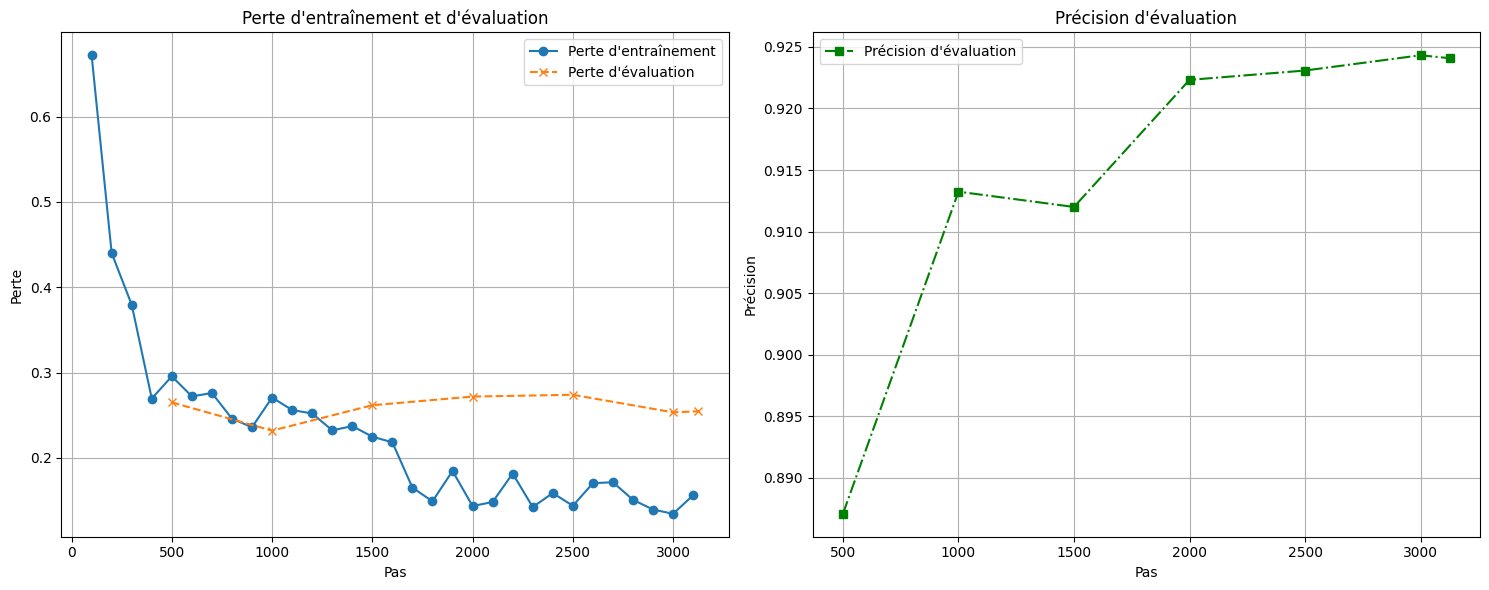

In [37]:
# ── Vérification : le trainer a-t-il bien été entraîné ? ─────────────────────
# POURQUOI cette garde ?
# → Donne un message clair au lieu d'un NameError cryptique
# → Rappelle à l'utilisateur l'ordre d'exécution attendu

try:
    _ = trainer
except NameError:
    raise RuntimeError(
        "❌ 'trainer' n'est pas défini.\n"
        "→ Exécutez d'abord la cellule BLOC 7 (création du Trainer)\n"
        "→ Puis la cellule BLOC 8 (trainer.train())\n"
        "→ Ensuite revenez ici."
    )

if not hasattr(trainer, 'state') or not trainer.state.log_history:
    raise RuntimeError(
        "❌ trainer.train() n'a pas encore été appelé ou n'a pas produit de logs.\n"
        "→ Assurez-vous que la cellule d'entraînement (trainer.train()) a été exécutée et s'est terminée correctement."
    )

# ── Visualisation (trainer garanti d'exister et d'avoir des logs) ─────────────
logs         = trainer.state.log_history
train_losses = [(l["step"], l["loss"]) for l in logs if "loss" in l and "eval_loss" not in l]
eval_logs    = [(l["step"], l["eval_loss"], l["eval_accuracy"]) for l in logs if "eval_loss" in l]

# Pour une meilleure lisibilité, nous allons visualiser les logs d'entraînement et d'évaluation.
# Note: Le reste du code de visualisation est dans les cellules suivantes ou sera ajouté.

print("Logs d'entraînement et d'évaluation disponibles.")
print(f"Nombre de pas d'entraînement loggués : {len(train_losses)}")
print(f"Nombre de pas d'évaluation loggués : {len(eval_logs)}")

# Nous allons maintenant tracer les courbes de perte et de métriques.
# Préparer les données pour le tracé
train_steps = [item[0] for item in train_losses]
train_values = [item[1] for item in train_losses]

eval_steps = [item[0] for item in eval_logs]
eval_losses = [item[1] for item in eval_logs]
eval_accuracies = [item[2] for item in eval_logs]

# Créer la figure et les axes
plt.figure(figsize=(15, 6))

# Tracé de la perte d'entraînement et d'évaluation
plt.subplot(1, 2, 1)
plt.plot(train_steps, train_values, label="Perte d'entraînement", marker='o', linestyle='-')
plt.plot(eval_steps, eval_losses, label="Perte d'évaluation", marker='x', linestyle='--')
plt.title("Perte d'entraînement et d'évaluation")
plt.xlabel("Pas")
plt.ylabel("Perte")
plt.legend()
plt.grid(True)

# Tracé de la précision d'évaluation
plt.subplot(1, 2, 2)
plt.plot(eval_steps, eval_accuracies, label="Précision d'évaluation", color='green', marker='s', linestyle='-.')
plt.title("Précision d'évaluation")
plt.xlabel("Pas")
plt.ylabel("Précision")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [38]:
print("=== ÉVALUATION FINALE SUR LE TEST SET ===")
eval_results = trainer.evaluate()

print(f"Loss     : {eval_results['eval_loss']:.4f}")
print(f"Accuracy : {eval_results['eval_accuracy']:.4f} ({eval_results['eval_accuracy']*100:.2f}%)")
print(f"F1-Score : {eval_results['eval_f1']:.4f}")

if eval_results["eval_accuracy"] >= 0.90:
    print("✅ Benchmark 90% ATTEINT — Modèle prêt pour un pilote")
else:
    print("⚠️  Benchmark non atteint — Essayer : 3 époques / roberta-base / nettoyage HTML")

# ── Rapport de classification détaillé ───────────────────────────────────────
# POURQUOI sklearn.classification_report ?
# → Montre précision ET rappel par classe séparément
# → En support client : le RAPPEL de la classe Négative est critique
#   (un faux négatif = client mécontent non détecté = churn silencieux)

from sklearn.metrics import classification_report

predictions_output = trainer.predict(tokenized_datasets["test"])
preds  = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

print("\n📈 Rapport de classification :")
print(classification_report(labels, preds,
      target_names=["Négatif", "Positif"], digits=4))

# LECTURE DU RAPPORT :
# Recall Négatif = parmi les vrais Négatif, combien avons-nous détectés ?
# → Objectif support client : Recall Négatif > 0.88

=== ÉVALUATION FINALE SUR LE TEST SET ===


Training Loss,Validation Loss,Step,Accuracy,F1
0.156166,0.253404,3126,0.924400,0.924391


Loss     : 0.2534
Accuracy : 0.9244 (92.44%)
F1-Score : 0.9244
✅ Benchmark 90% ATTEINT — Modèle prêt pour un pilote



📈 Rapport de classification :
              precision    recall  f1-score   support

     Négatif     0.9337    0.9137    0.9236     12500
     Positif     0.9155    0.9351    0.9252     12500

    accuracy                         0.9244     25000
   macro avg     0.9246    0.9244    0.9244     25000
weighted avg     0.9246    0.9244    0.9244     25000



In [39]:
# ── Sauvegarde ────────────────────────────────────────────────────────────────
SAVE_PATH = "./bert_sentiment_final"
trainer.save_model(SAVE_PATH)           # Modèle + config
tokenizer.save_pretrained(SAVE_PATH)    # Tokenizer
print(f"Modèle sauvegardé dans {SAVE_PATH}/")

# ── API haut niveau HuggingFace pipeline() ────────────────────────────────────
# POURQUOI pipeline() en production ?
# → Gestion automatique device, batching, format de sortie standard
# → Compatible HuggingFace Inference API, déploiement AWS SageMaker

from transformers import pipeline as hf_pipeline

sentiment_pipe = hf_pipeline(
    "text-classification",
    model=SAVE_PATH,
    tokenizer=SAVE_PATH,
    device=0 if torch.cuda.is_available() else -1
)

test_text = "This support team is absolutely fantastic!"
result = sentiment_pipe(test_text)[0]
print(f"Test rechargement : {result['label']} (score={result['score']:.4f})")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modèle sauvegardé dans ./bert_sentiment_final/


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Test rechargement : POSITIF (score=0.9973)


TEXTE BRUT ("I want a refund!")
    │
    ▼
[AutoTokenizer bert-base-uncased]
    │
    ├── input_ids      [101, 1045, 2215, 1037, ...]  ← indices vocab (30 522 tokens)
    ├── attention_mask [1,   1,    1,    1,    ...]  ← 1=réel, 0=padding
    └── token_type_ids [0,   0,    0,    0,    ...]  ← tout 0 = séquence unique
    │
    ▼ [DataCollatorWithPadding]
    │   Padde jusqu'au texte le plus long du batch (dynamic)
    │
    ▼
[BertForSequenceClassification]
    ├── BERT Encoder (12 couches Transformer bidirectionnel)
    │       ↓
    │   Vecteur [CLS] — 768 dimensions
    │       ↓
    └── Dropout(0.1) → Dense(768→2) → Logits [l_neg, l_pos]
    │
    ▼ [softmax — en inférence uniquement]
    │
    [0.08, 0.92]  →  POSITIF · confiance=0.920
    │
    ▼
RÈGLE MÉTIER → ACTION SUPPORT